IMPORT LIBRARIES



In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

 LOAD DATASET

In [28]:
df = pd.read_csv("/content/creditcard.csv")

DATA CLEANING

In [29]:
print(df.isnull().sum())
df = df.drop_duplicates()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       1
V11       1
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


 DESCRIPTIVE STATISTICS

In [30]:
print(df.describe())

print("\nAverage Amount:", df['Amount'].mean())
print("\nFraud Count:\n", df['Class'].value_counts())

               Time            V1            V2            V3            V4  \
count  82970.000000  82970.000000  82970.000000  82970.000000  82970.000000   
mean   38193.955864     -0.256024     -0.042401      0.680033      0.161240   
std    15492.520992      1.873652      1.670117      1.372255      1.365151   
min        0.000000    -56.407510    -72.715728    -33.680984     -5.172595   
25%    31284.000000     -1.018474     -0.604391      0.185729     -0.726093   
50%    40777.000000     -0.252149      0.068177      0.763759      0.182415   
75%    50286.000000      1.153576      0.719508      1.392099      1.039738   
max    59769.000000      1.960497     18.902453      4.226108     16.715537   

                 V5            V6            V7            V8            V9  \
count  82970.000000  82970.000000  82970.000000  82970.000000  82970.000000   
mean      -0.275894      0.093811     -0.112235      0.052427     -0.019188   
std        1.379729      1.305778      1.243376    

RISK ANALYSIS

In [31]:
def risk(x):
    if x < 100:
        return "Low Risk"
    elif x < 1000:
        return "Medium Risk"
    else:
        return "High Risk"

df['Risk_Level'] = df['Amount'].apply(risk)

VISUALIZATIONS



Fraud Distribution

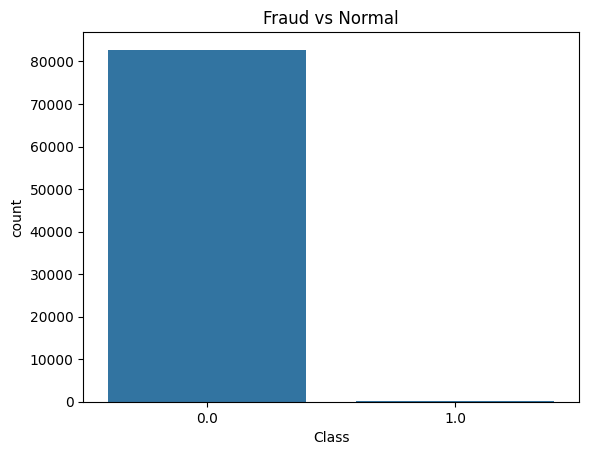

In [32]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal")
plt.show()

Amount Distribution


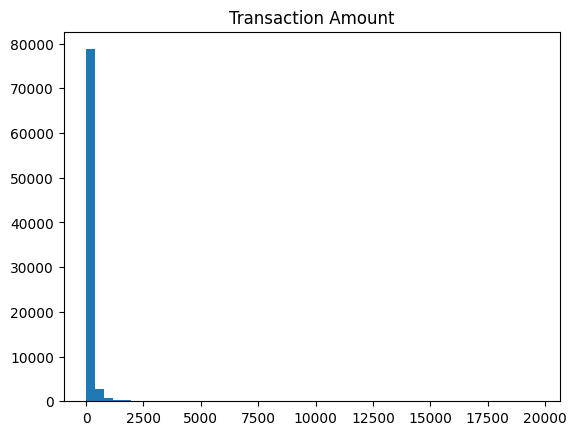

In [33]:
plt.hist(df['Amount'], bins=50)
plt.title("Transaction Amount")
plt.show()

Fraud vs Amount


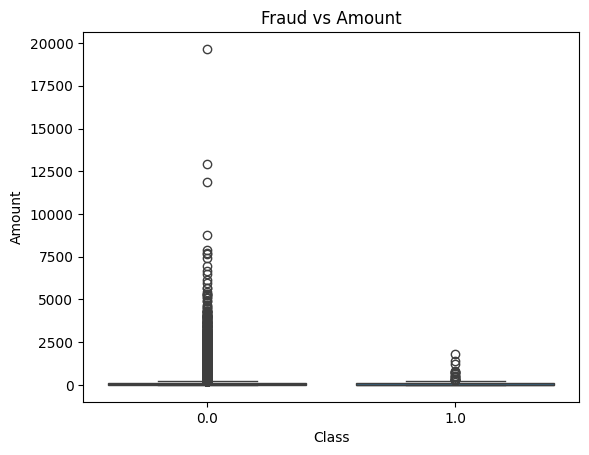

In [34]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Fraud vs Amount")
plt.show()

Time vs Amount


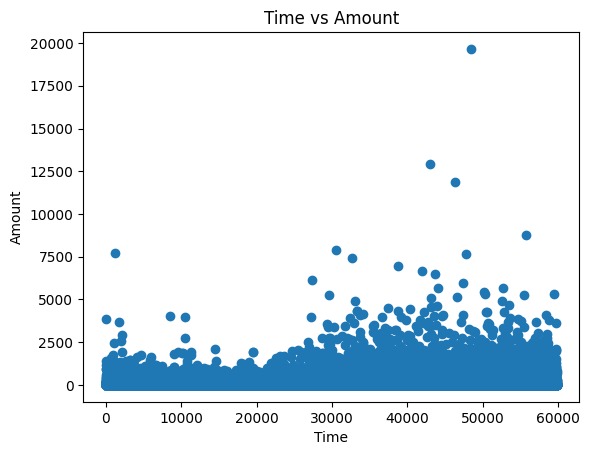

In [35]:
plt.scatter(df['Time'], df['Amount'])
plt.title("Time vs Amount")
plt.xlabel("Time")
plt.ylabel("Amount")
plt.show()

Correlation Heatmap


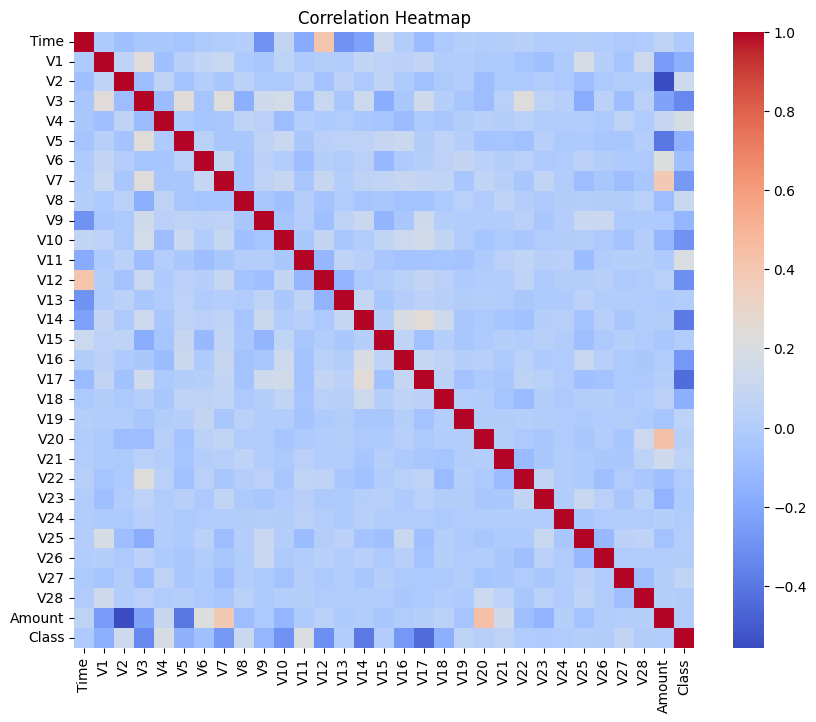

In [36]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

HANDLE MISSING VALUES


In [37]:
df = df.fillna(df.mean(numeric_only=True))

 LINEAR REGRESSION


In [38]:
X = df[['Time', 'Amount']]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

MODEL EVALUATION



In [39]:
print("\nR2 Score:", r2_score(y_test, y_pred))


R2 Score: -0.00020388776470703363


INTERACTIVE DASHBOARD




Fraud Distribution Dashboard

In [40]:
fig1 = px.pie(df, names='Class',
              title='Fraud Distribution')
fig1.show()

Amount Trend Dashboard


In [41]:
fig2 = px.histogram(df, x='Amount',
                    title='Transaction Amount Distribution')
fig2.show()

Scatter Dashboard


In [42]:
fig3 = px.scatter(df, x='Time', y='Amount',
                  color='Class',
                  title='Fraud Comparison')
fig3.show()

FINAL INSIGHTS


In [43]:
print("\nInsights:")
print("• Fraud transactions are very less")
print("• High amount transactions may be risky")
print("• Heatmap shows important feature relationships")
print("• Dashboard helps understand fraud patterns")


Insights:
• Fraud transactions are very less
• High amount transactions may be risky
• Heatmap shows important feature relationships
• Dashboard helps understand fraud patterns
